# Занятие 5. Меры связи и линейная регрессия

В этой лекции мы разберём два фундаментальных инструмента количественного анализа данных: **корреляцию** и **линейную регрессию**. Они лежат в основе большинства методов машинного обучения и статистики, поэтому важно не просто уметь вызывать функции, но и понимать, что именно они измеряют, когда работают, а когда дают ложный ответ.

---

### Ключевые термины

**Признаки (features)** — входные переменные, которые мы используем для предсказания. В таблице это все столбцы, кроме того, что мы хотим предсказать.

**Целевая переменная (таргет, target)** — то, что мы хотим предсказать. Это единственный столбец, который модель не «видит» во время обучения, а учится воспроизводить.

---

### Датасет: California Housing

Данные о жилье в Калифорнии 1990 года. 20 640 домохозяйств.

**Целевая переменная (таргет):** `MedHouseVal` — медианная стоимость дома в блоке, в сотнях тысяч долларов. Именно её мы будем предсказывать.

**Признаки:**

| Признак | Расшифровка | Единицы |
|---|---|---|
| `MedInc` | Медианный доход домохозяйств в блоке | десятки тысяч долларов |
| `HouseAge` | Медианный возраст домов в блоке | лет |
| `AveRooms` | Среднее число комнат на домохозяйство | комнат |
| `AveBedrms` | Среднее число спален на домохозяйство | комнат |
| `Population` | Численность населения блока | человек |
| `AveOccup` | Среднее число жильцов на домохозяйство | человек |
| `Latitude` | Географическая широта блока | градусы |
| `Longitude` | Географическая долгота блока | градусы |

> **Блок** — минимальная единица переписи населения в США, обычно 600–3000 человек.

## Базовые импорты и данные

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')  # игнорировать предупреждения
# np.random.seed(42)  # для воспроизводимости

# Датасет: цены на жильё в Калифорнии, 20 640 домохозяйств
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
# Часть I. Проверка нормальности распределения

## 1. Зачем это нужно

Многие статистические методы — в том числе корреляция Пирсона и линейная регрессия — предполагают, что данные распределены нормально (или близко к тому). Прежде чем применять эти методы, полезно проверить это предположение.

Кроме того, понимание формы распределения помогает:
- Выбрать подходящую меру корреляции (Пирсон vs Спирмен)
- Обнаружить выбросы и скошенность
- Правильно интерпретировать среднее (при сильной асимметрии оно нерепрезентативно)

---

## 2. Как выглядит нормальное распределение

Нормальное (гауссово) распределение симметрично, колоколообразно и полностью задаётся двумя параметрами: средним $\mu$ и стандартным отклонением $\sigma$.

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

**Правило трёх сигм:**
- В диапазоне $\mu \pm \sigma$ находится ~68% наблюдений
- В диапазоне $\mu \pm 2\sigma$ — ~95%
- В диапазоне $\mu \pm 3\sigma$ — ~99.7%

На практике идеально нормальных данных почти не бывает. Поэтому говорят об **околонормальном** распределении — достаточно близком к нормальному для применения соответствующих методов.

## 3. Асимметрия и эксцесс

Два числовых показателя, которые описывают форму распределения.

### Асимметрия (Skewness)

Показывает, насколько распределение скошено относительно среднего.

$$\text{skewness} = \frac{1}{n}\sum\left(\frac{x_i - \bar{x}}{s}\right)^3$$

| Значение | Интерпретация |
|---|---|
| ≈ 0 | симметричное (нормальное) |
| > 0 | правосторонняя асимметрия: длинный «хвост» вправо, медиана < среднего |
| < 0 | левосторонняя асимметрия: длинный «хвост» влево, медиана > среднего |


Пример с доходами: большинство людей зарабатывают мало, единицы — очень много. Распределение скошено вправо (skewness >> 0), среднее намного выше медианы.

### Эксцесс (Kurtosis)

Показывает «остроту» пика и тяжесть хвостов по сравнению с нормальным распределением.

$$\text{kurtosis} = \frac{1}{n}\sum\left(\frac{x_i - \bar{x}}{s}\right)^4 - 3$$

Если просто посчитать формулу без вычитания, нормальное распределение давало бы kurtosis = 3, а не 0. Чтобы сделать нормальное распределение точкой отсчёта (нулём), из результата вычитают эту тройку — отсюда и название excess kurtosis («избыточный» эксцесс, то есть сверх нормального).

| Значение | Интерпретация |
|---|---|
| ≈ 0 | нормальное распределение |
| > 0 | острый пик, тяжёлые хвосты (много выбросов) |
| < 0 | плоское распределение, лёгкие хвосты |

**Практическое правило:** если |ассиметрия| < 2 и |эксцесс| < 2 — распределение можно считать **околонормальным** (мягкий критерий, применяемый на практике при больших выборках; при строгом подходе используют порог < 0.5).

### Импорты: визуализация и статистика

`matplotlib` и `seaborn` — для графиков. `scipy.stats` — для статистических тестов (в т.ч. вычисления корреляции и p-value).

In [ ]:
# Инструменты для визуализации и статистических тестов
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False # для красивой визуализации просто уберём верхнюю и правую границы
plt.rcParams['axes.spines.right'] = False

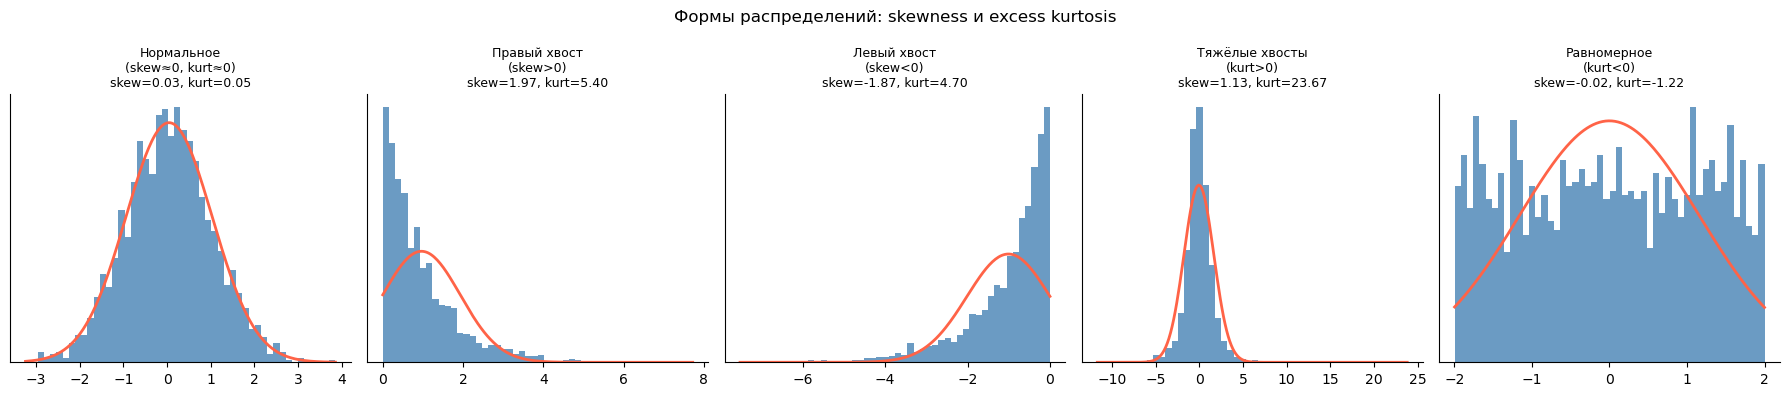

In [ ]:
# Демонстрация: разные формы распределений и их skewness/kurtosis
np.random.seed(42)
n = 2000

distributions = {
    "Нормальное\n(skew≈0, kurt≈0)":   np.random.normal(0, 1, n),
    "Правый хвост\n(skew>0)":          np.random.exponential(1, n),
    "Левый хвост\n(skew<0)":           -np.random.exponential(1, n),
    "Тяжёлые хвосты\n(kurt>0)":        np.random.standard_t(df=3, size=n),
    "Равномерное\n(kurt<0)":           np.random.uniform(-2, 2, n),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (title, data) in zip(axes, distributions.items()):
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)  # excess kurtosis
    ax.hist(data, bins=50, color='steelblue', alpha=0.8, edgecolor='none', density=True)
    # Кривая нормального распределения для сравнения
    xx = np.linspace(data.min(), data.max(), 200)
    ax.plot(xx, stats.norm.pdf(xx, data.mean(), data.std()),
            'tomato', linewidth=2, label='норм.')
    ax.set_title(f"{title}\nskew={skew:.2f}, kurt={kurt:.2f}", fontsize=9)
    ax.set_yticks([])

fig.suptitle('Формы распределений: skewness и excess kurtosis', fontsize=12)
plt.tight_layout()
plt.show()

**Что видно:**
- Нормальное распределение — симметрично, skew ≈ 0, kurt ≈ 0. Красная кривая совпадает с гистограммой.
- Экспоненциальное — длинный правый хвост, skew > 0. Среднее «утащено» вправо.
- Распределение Стьюдента с малым числом степеней свободы — острый пик и тяжёлые хвосты, kurt > 0. Много выбросов.
- Равномерное — плоское, kurt < 0. Нет концентрации около центра.

## 4. Тест Шапиро-Уилка

Числовые показатели (skewness, kurtosis) описывают форму, но не дают формального ответа на вопрос «нормальное ли это распределение?». Для этого используют статистические тесты.

**Тест Шапиро-Уилка** — наиболее мощный тест на нормальность для выборок малого и среднего размера. Формально scipy принимает до 5000 наблюдений, но на практике при n > 300–500 любое небольшое отклонение уже даёт p < 0.05 из-за высокой мощности теста. Поэтому в коде используется подвыборка 500 наблюдений — это достаточно для диагностики формы без ложных срабатываний на больших выборках.

**Гипотезы:**
- H₀: данные происходят из нормального распределения
- H₁: данные не нормально распределены

**Интерпретация p-value:**

| p-value | Вывод |
|---|---|
| > 0.05 | нет оснований отвергнуть нормальность |
| < 0.05 | отвергаем нормальность |

> **Ловушка больших выборок:** при n > 1000–2000 тест Шапиро-Уилка почти всегда даёт p < 0.05 — даже для почти нормальных данных. Любое микроскопическое отклонение становится «значимым». Поэтому при больших выборках смотрите на skewness, kurtosis и гистограмму, а тест используйте как вспомогательный инструмент.

```python
stat, p = stats.shapiro(data)
# stat — тестовая статистика W (близко к 1 = нормально)
# p   — p-value
```

## 5. Комплексная проверка нормальности

На практике нормальность проверяют тремя способами вместе:
1. **Гистограмма с кривой нормального распределения** — визуальная оценка
2. **Skewness и kurtosis** — числовая оценка формы
3. **Тест Шапиро-Уилка** — формальная проверка

Посмотрим на несколько признаков из California Housing и применим все три инструмента.

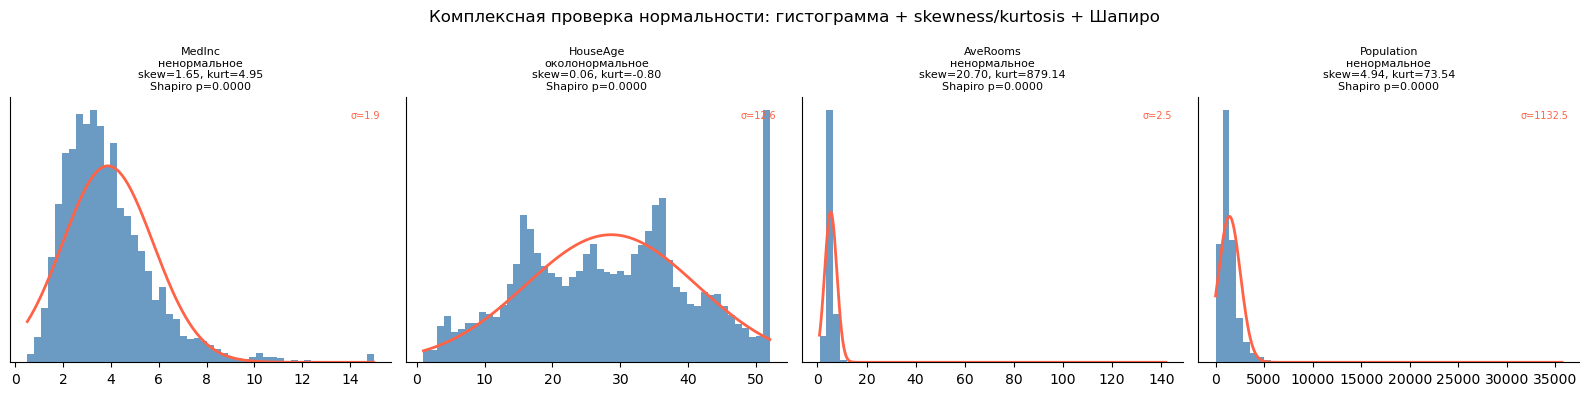

In [ ]:
check_cols = ['MedInc', 'HouseAge', 'AveRooms', 'Population']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for col_idx, col in enumerate(check_cols):
    data = df[col].dropna()

    skew = stats.skew(data)
    kurt = stats.kurtosis(data)

    sample = data.sample(min(500, len(data)), random_state=42)
    stat_w, p_sh = stats.shapiro(sample)

    if abs(skew) < 2 and abs(kurt) < 2 and p_sh > 0.05:
        verdict = "нормальное"
    elif abs(skew) < 2 and abs(kurt) < 2:
        verdict = "околонормальное"
    else:
        verdict = "ненормальное"

    mu, sigma = data.mean(), data.std()

    # Диапазон колокола: μ ± 4σ — нормальное распределение симметрично и полностью видно
    x_min = mu - 4 * sigma
    x_max = mu + 4 * sigma
    xx = np.linspace(x_min, x_max, 300)

    ax = axes[col_idx]
    ax.hist(data, bins=50, density=True,
            color='steelblue', alpha=0.8, edgecolor='none')
    xx = np.linspace(data.min(), data.max(), 300)
    ax.plot(xx, stats.norm.pdf(xx, mu, sigma), 'tomato', linewidth=2, label='норм.')
    # Подпись объясняет студенту почему колокол плоский
    ax.text(0.97, 0.95, f'σ={sigma:.1f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=7, color='tomato')
    ax.set_title(
        f'{col}\n{verdict}\nskew={skew:.2f}, kurt={kurt:.2f}\nShapiro p={p_sh:.4f}',
        fontsize=8
    )
    ax.set_yticks([])
    # ax.legend(fontsize=7)

fig.suptitle('Комплексная проверка нормальности: гистограмма + skewness/kurtosis + Шапиро',
             fontsize=12)
plt.tight_layout()
plt.show()

Красная линия - а как бы выглядело нормальное распределение, если бы имело то же среднее и то же стандартное отклонение, что и наши данные?

---
# Часть II. Корреляция

## 1. Что такое корреляция и зачем она нужна

Представьте: вы хотите предсказать цену квартиры. Логично предположить, что она зависит от площади, района, этажа. Но как **количественно** оценить, насколько сильна эта зависимость? Именно для этого используется корреляция.

**Корреляция** — это мера статистической связи между двумя числовыми переменными. Она отвечает на вопрос: «Если одна переменная растёт, что происходит с другой?»

Коэффициент корреляции принимает значения от −1 до +1:

| Значение | Интерпретация |
|---|---|
| +1 | идеальная положительная линейная связь |
| от +0.5 до +1 | сильная положительная связь |
| от +0.2 до +0.5 | умеренная положительная связь |
| от 0 до +0.2 | слабая положительная связь |
| около 0 | связи нет (или она нелинейная) |
| от −0.2 до 0 | слабая отрицательная связь |
| от −0.5 до −0.2 | умеренная отрицательная связь |
| от −1 до −0.5 | сильная отрицательная связь |
| −1 | идеальная отрицательная линейная связь |

**Ключевые свойства:**
- Безразмерна — не зависит от единиц измерения X и Y
- Симметрична: corr(X, Y) = corr(Y, X)
- **Корреляция ≠ причинность** — это важнейшее ограничение, к которому мы ещё вернёмся

Существуют разные коэффициенты корреляции. Выбор зависит от природы данных и типа связи. В этой лекции рассмотрим два основных: **Пирсона** (линейная связь) и **Спирмена** (монотонная связь).

## 2. Коэффициент корреляции Пирсона

Коэффициент Пирсона измеряет **линейную** связь между двумя непрерывными переменными.

### Формула

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n(x_i-\bar{x})^2} \cdot \sqrt{\sum_{i=1}^n(y_i-\bar{y})^2}}$$

Числитель — **ковариация**: произведение отклонений X и Y от своих средних. Если X и Y отклоняются в одну сторону — числитель положителен. Если в разные — отрицателен. Знаменатели нормируют результат в отрезок [−1, 1].

Компактно: $r = \dfrac{\text{cov}(X, Y)}{s_X \cdot s_Y}$

### Требования и ограничения

- Оба признака должны быть **непрерывными**
- Желательна нормальность распределений (важно для корректности p-value)
- **Очень чувствителен к выбросам** — один выброс может кардинально изменить значение
- Улавливает только **линейную** связь: нелинейную монотонную связь занижает или не видит вовсе

## 3. Коэффициент корреляции Спирмена

Коэффициент Спирмена измеряет **монотонную** связь. «Монотонная» — значит, что с ростом X значения Y тоже возрастают (или убывают), но не обязательно линейно.

### Как он устроен

Алгоритм прост:
1. Заменить значения X и Y их **рангами** (1 = наименьшее значение)
2. Применить формулу Пирсона к рангам

Эквивалентная формула (при отсутствии совпадений рангов):
$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}, \quad d_i = \text{rank}(x_i) - \text{rank}(y_i)$$

Переход к рангам — это и есть секрет устойчивости Спирмена: выброс влияет только на один ранг, а не «тянет» всё облако точек.

### Сравнение с Пирсоном

| | Пирсон | Спирмен |
|---|---|---|
| Тип связи | только линейная | любая монотонная |
| Чувствительность к выбросам | высокая | низкая |
| Требования к распределению | нормальность желательна | нет требований |
| Порядковые данные (шкалы, ранги) | не подходит | подходит |

### Когда что использовать

Используйте **Спирмена**, если:
- данные содержат выбросы
- распределение сильно скошено (доходы, цены на жильё, количество просмотров)
- данные порядковые (оценки от 1 до 5, ранги)
- вы подозреваете нелинейную монотонную зависимость

### Диагностическая ценность разницы

Большая разница между r (Пирсон) и ρ (Спирмен) сама по себе — ценный сигнал. Если r ≪ ρ, скорее всего, в данных есть выбросы или нелинейность. Если оба близки — связь линейна и данные «чистые».

> **Практика:** в реальном анализе полезно всегда считать оба коэффициента и сравнивать.

### Визуализация: Пирсон vs Спирмен в разных ситуациях

Посмотрим на 8 разных сценариев. Обратите внимание на случаи, где коэффициенты **расходятся** — именно там скрыта важная информация о данных.

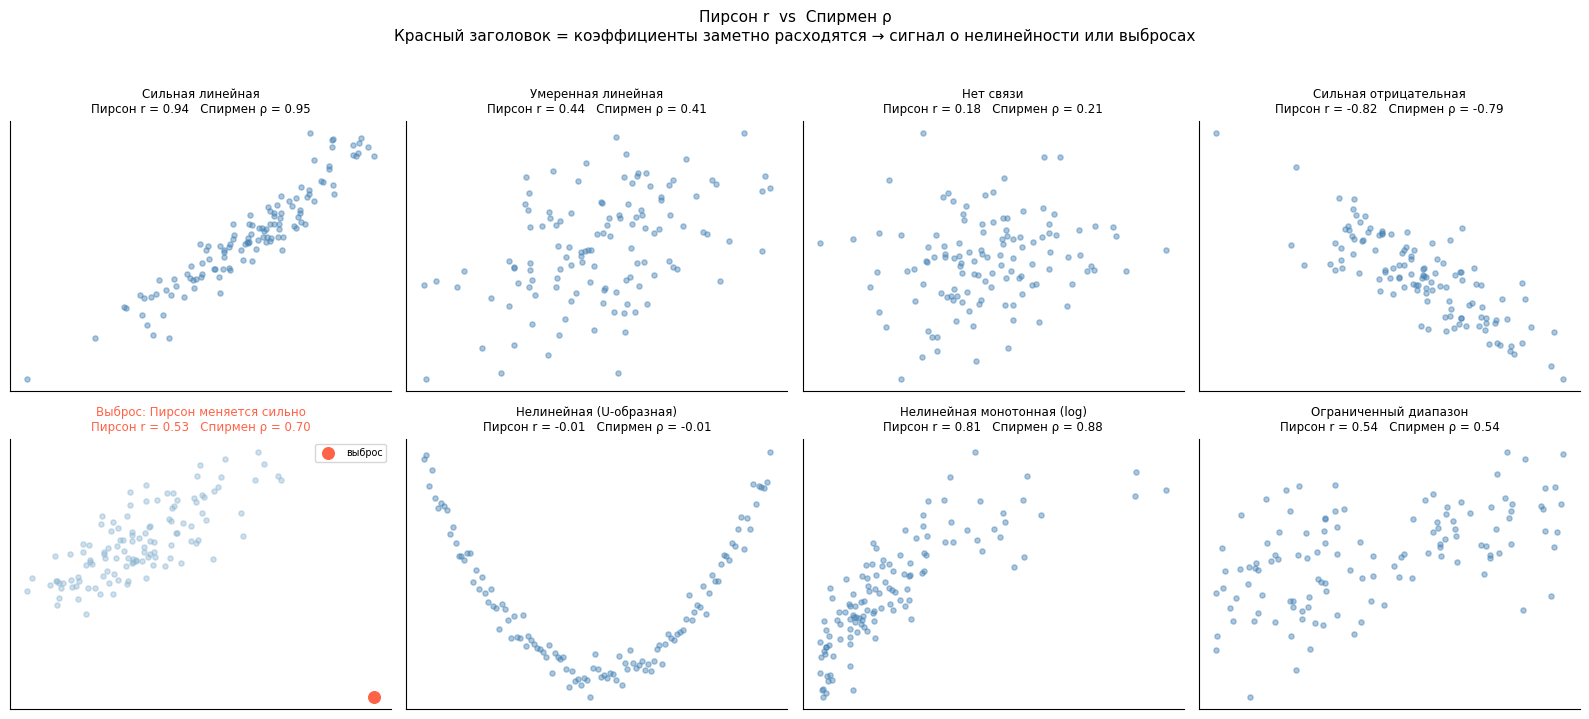

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
configs = [
    (0.95,  "Сильная линейная", False, False),
    (0.50,  "Умеренная линейная", False, False),
    (0.05,  "Нет связи", False, False),
    (-0.85, "Сильная отрицательная", False, False),
    (0.85,  "Выброс: Пирсон меняется сильно", True, False),
    (0.0,   "Нелинейная (U-образная)", False, True),
    (0.0,   "Нелинейная монотонная (log)", False, False),
    (0.0,   "Ограниченный диапазон", False, False),
]

for idx, ax in enumerate(axes.flat):
    r_target, title, add_outlier, quadratic = configs[idx]
    n = 120

    if quadratic:
        x = np.linspace(-3, 3, n)
        y = x**2 + np.random.randn(n)*0.4
    elif title.startswith("Нелинейная монотонная"):
        x = np.random.exponential(scale=2, size=n)
        y = np.log1p(x) + np.random.randn(n)*0.3
    elif title.startswith("Ограниченный"):
        x_full = np.random.randn(500)
        y_full = 0.9*x_full + np.random.randn(500)*0.4
        mask = (x_full > -0.5) & (x_full < 0.5)
        x, y = x_full[mask][:n], y_full[mask][:n]
    else:
        cov = np.array([[1, r_target],[r_target, 1]])
        data = np.random.multivariate_normal([0,0], cov, n)
        x, y = data[:,0], data[:,1]
        if add_outlier:
            x = np.append(x, [4])
            y = np.append(y, [-4])

    r_p, _ = stats.pearsonr(x, y)
    r_s, _ = stats.spearmanr(x, y)
    big_diff = abs(abs(r_p) - abs(r_s)) > 0.12 or (r_p * r_s < 0)

    ax.scatter(x, y, alpha=0.45, s=14,
               color='steelblue' if not add_outlier else '#90b8d4')
    if add_outlier:
        ax.scatter([x[-1]], [y[-1]], color='tomato', s=70, zorder=5, label='выброс')
        ax.legend(fontsize=7, loc='upper right')

    color = 'tomato' if big_diff else 'black'
    ax.set_title(
        f"{title}\nПирсон r = {r_p:.2f}   Спирмен ρ = {r_s:.2f}",
        fontsize=8.5, color=color
    )
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(
    "Пирсон r  vs  Спирмен ρ\n"
    "Красный заголовок = коэффициенты заметно расходятся → сигнал о нелинейности или выбросах",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## 4. Значимость корреляции

Коэффициент корреляции, вычисленный из выборки — это лишь **оценка**. Нужно проверить: не возник ли он случайно при данном объёме выборки?

**Гипотезы:**
- H₀: корреляция в генеральной совокупности равна нулю (ρ = 0)
- H₁: корреляция не равна нулю

**Тестовая статистика:**
$$t = r\sqrt{\frac{n-2}{1-r^2}}, \quad t \sim t_{n-2}$$

**p-value** — вероятность получить |r| ≥ наблюдаемого, если H₀ верна. Если p < 0.05, отвергаем H₀.

### Ловушка больших выборок

> При большом n **даже крошечная корреляция становится статистически значимой**. Это не означает, что она практически важна.

Правило: всегда смотрите **и на p-value, и на само значение r**.


In [ ]:
# Зафиксируем «истинную» корреляцию в генеральной совокупности — небольшую, но не нулевую
r_fixed = 0.12

# Размеры выборок, которые будем проверять
ns = [20, 50, 100, 300, 1000, 5000]

print(f"Фиксированная корреляция r ≈ {r_fixed} — небольшая, но не нулевая\n")
print(f"{'n':>6}  {'реальный r':>10}  {'p-value':>10}  {'значима?':>12}  {'вывод'}")
print("─" * 70)

for n in ns:
    # Матрица ковариаций для двумерного нормального распределения:
    # диагональ = дисперсии X и Y (обе = 1),
    # внедиагональные элементы = ковариация = корреляция (т.к. дисперсии = 1)
    cov = np.array([[1,       r_fixed],
                    [r_fixed, 1      ]])

    # Генерируем n пар (x, y) с «зашитой» корреляцией r_fixed.
    # [0, 0] — средние X и Y. Результат: массив формы (n, 2)
    data = np.random.multivariate_normal([0, 0], cov, n)

    # Считаем корреляцию по выборке.
    # r_obs ≠ r_fixed, потому что выборка случайная — особенно заметно при малом n
    r_obs, p = stats.pearsonr(data[:, 0], data[:, 1])

    # Стандартный порог значимости: p < 0.05 → отвергаем H₀ «корреляция = 0»
    sig = "ДА ✓" if p < 0.05 else "нет"

    # Ловушка больших выборок: корреляция статистически значима (p < 0.05),
    # но при этом мала по величине (|r| < 0.2) → практически бесполезна
    r2_explained = r_obs**2 * 100  # сколько % дисперсии объясняет эта корреляция
    comment = f"⚠ значима, объясняет {r2_explained:.1f}% дисперсии" if p < 0.05 else ""
    print(f"{n:>6}  {r_obs:>10.3f}  {p:>10.4f}  {sig:>12}  {comment}")

Фиксированная корреляция r ≈ 0.12 — небольшая, но не нулевая

     n  реальный r     p-value      значима?  вывод
──────────────────────────────────────────────────────────────────────
    20      -0.005      0.9844           нет  
    50       0.030      0.8362           нет  
   100       0.077      0.4452           нет  
   300       0.114      0.0482          ДА ✓  ⚠ значима, объясняет 1.3% дисперсии
  1000       0.095      0.0026          ДА ✓  ⚠ значима, объясняет 0.9% дисперсии
  5000       0.097      0.0000          ДА ✓  ⚠ значима, объясняет 0.9% дисперсии


---
# Часть III. Корреляционная матрица и визуализация связей

## 1. Корреляционная матрица

Когда признаков много, считать корреляцию попарно вручную неудобно. **Корреляционная матрица** делает это сразу для всех пар — результат r×r матрица, где r — количество переменных.

**Что в ней смотреть:**

- **Строка таргета** — какие признаки сильнее всего связаны с тем, что мы предсказываем
- **Пары предикторов** с высокой корреляцией между собой — сигнал о мультиколлинеарности (об этом подробнее далее)
- **Знак** — положительная или отрицательная связь

Диагональ всегда равна 1: переменная идеально коррелирует сама с собой.

### Визуализация: тепловая карта (heatmap)

Тепловая карта — стандартный способ отобразить корреляционную матрицу. `cmap='coolwarm'` с `center=0` даёт интуитивную цветовую шкалу: синий = отрицательная, красный = положительная, белый = нет связи.

Верхний треугольник симметричен нижнему, поэтому его часто маскируют для читаемости.

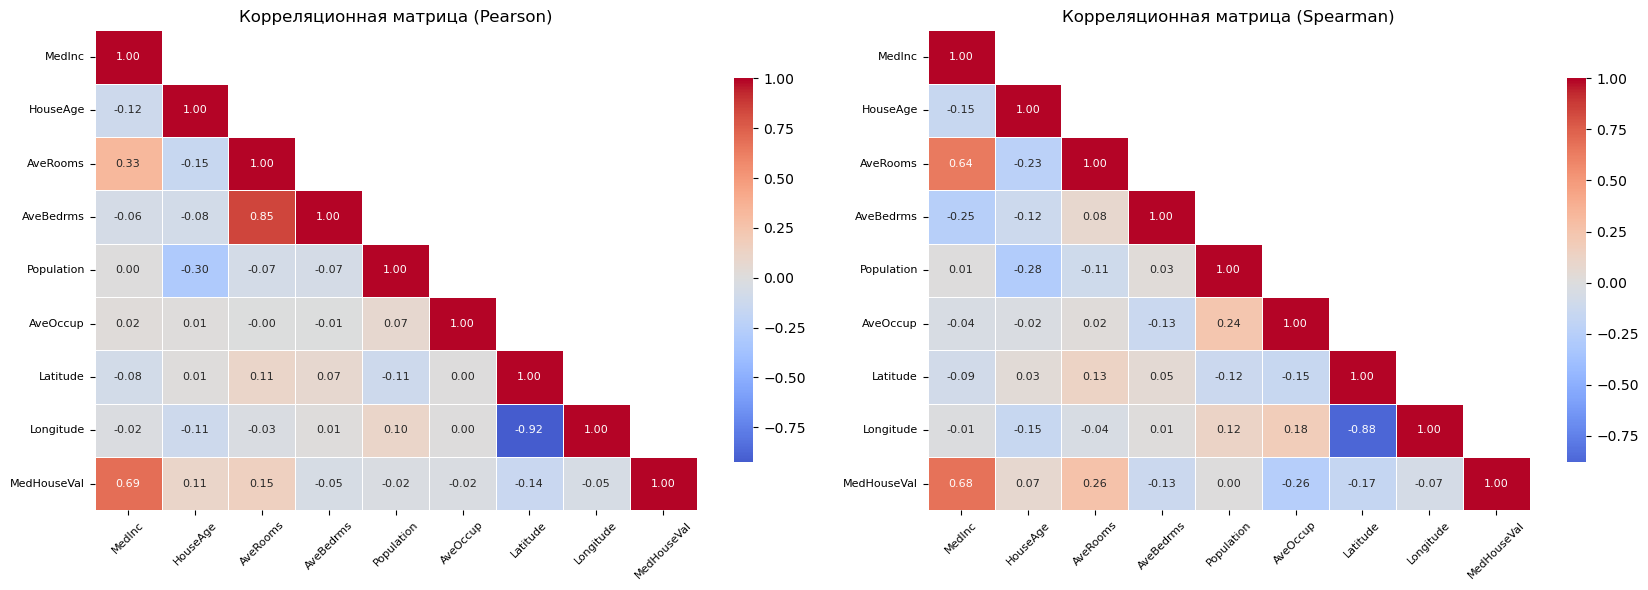

In [ ]:
target_col  = 'MedHouseVal'
feature_cols = [c for c in df.columns if c != target_col]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, method in zip(axes, ['pearson', 'spearman']):
    matrix = df.corr(method=method)
    # np.triu возвращает верхний треугольник матрицы.
    # mask=True скрывает ячейку, поэтому верхний треугольник будет скрыт,
    # а нижний (включая диагональ) — показан. k=1 означает: начинать с 1-й наддиагонали
    # (т.е. саму диагональ оставить видимой).
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.4, ax=ax, mask=mask,
                cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
    ax.set_title(f'Корреляционная матрица ({method.capitalize()})', fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Топ признаков по корреляции с таргетом — оба метода
corr_p = df.corr(method='pearson')[target_col].drop(target_col)
corr_s = df.corr(method='spearman')[target_col].drop(target_col)

comparison = pd.DataFrame({
    'Пирсон r': corr_p.round(3),
    'Спирмен ρ': corr_s.round(3),
    'Разница |r|−|ρ|': (corr_p.abs() - corr_s.abs()).round(3)
}).sort_values('Спирмен ρ', key=abs, ascending=False)

print(f"Корреляция признаков с таргетом '{target_col}':")
print(comparison.to_string())

Корреляция признаков с таргетом 'MedHouseVal':
            Пирсон r  Спирмен ρ  Разница |r|−|ρ|
MedInc         0.688      0.677            0.011
AveRooms       0.152      0.263           -0.111
AveOccup      -0.024     -0.257           -0.233
Latitude      -0.144     -0.166           -0.022
AveBedrms     -0.047     -0.125           -0.078
HouseAge       0.106      0.075            0.031
Longitude     -0.046     -0.070           -0.024
Population    -0.025      0.004            0.021


## 2. Матрица диаграмм рассеивания (Scatter Matrix / Pairplot)

Корреляционная матрица даёт числа, но **скрывает форму зависимости**. Scatter matrix показывает её визуально.

**Структура:**
- Вне диагонали — scatter plot для каждой пары признаков
- На диагонали — гистограмма или KDE для одного признака (одномерное распределение)

**Что искать:**
- Линейные или нелинейные зависимости
- Кластеры (возможная категориальная структура в непрерывных данных)
- Выбросы, которые не были видны поодиночке
- Пары с сильной взаимной корреляцией — будущая мультиколлинеарность

> **Практическое ограничение:** при большом числе признаков pairplot становится нечитаемым. Стандартная практика — брать топ-4/5 признаков по корреляции с таргетом, остальное фильтруется корреляционной матрицей.

Признаки для pairplot: ['MedInc', 'AveRooms', 'AveOccup', 'Latitude', 'MedHouseVal']


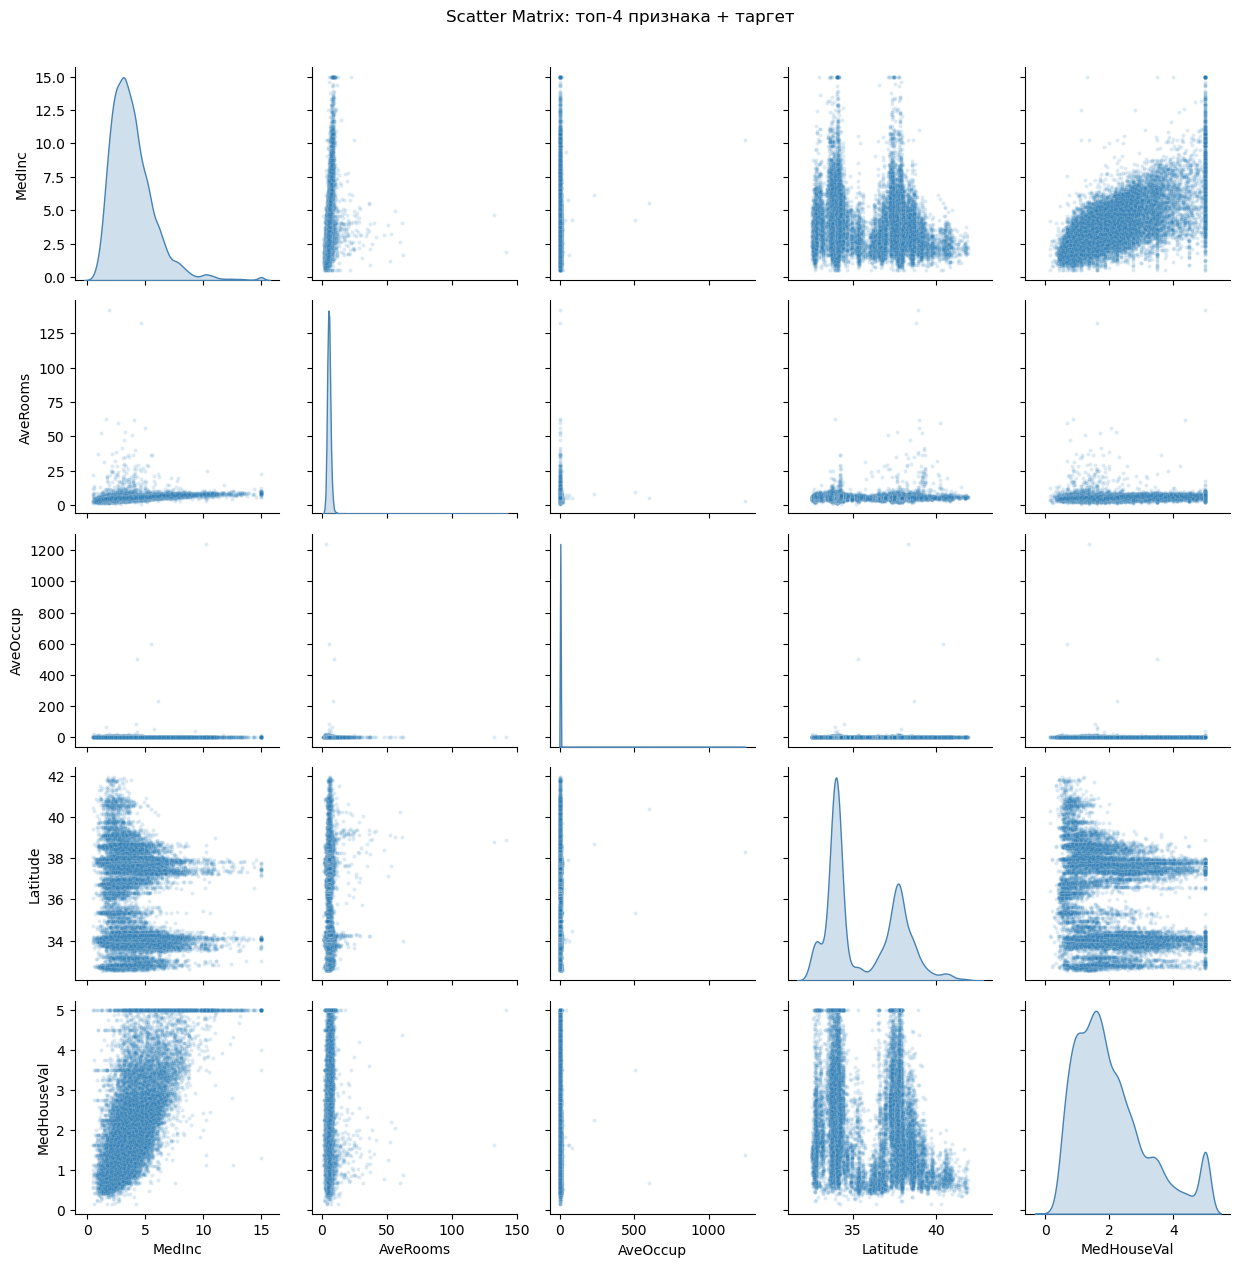

In [ ]:
# Топ-4 признака по Спирмену + таргет
top4 = comparison['Спирмен ρ'].abs().nlargest(4).index.tolist()
cols_plot = top4 + [target_col]
print("Признаки для pairplot:", cols_plot)

g = sns.pairplot(df[cols_plot], diag_kind='kde',
                 plot_kws={'alpha': 0.15, 's': 8},
                 diag_kws={'fill': True, 'color': 'steelblue'})
g.fig.suptitle('Scatter Matrix: топ-4 признака + таргет', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 3. Ловушки и ограничения корреляционного анализа

### 3.1 Корреляция ≠ причинность

Это самая частая ошибка в интерпретации данных. Несколько классических примеров:

- Продажи мороженого и количество утоплений коррелируют — виновата жара (скрытая переменная)
- Количество пожарных машин на пожаре и ущерб коррелируют положительно — больший пожар требует и того, и другого
- В странах с большим количеством телевизоров выше продолжительность жизни — обе переменные отражают уровень богатства

### 3.2 Ограниченный диапазон (аттенюация)

Если вы анализируете данные только из узкого диапазона X, корреляция будет **занижена** — даже если на полном диапазоне она сильная. Это явление называется **аттенюацией корреляции** (от лат. *attenuare* — ослаблять).

Пример: отбор кандидатов по минимальному баллу приводит к тому, что внутри отобранной группы корреляция «балл — успех» почти исчезает — мы просто не видим весь диапазон переменной.

> **Практический вывод:** если данные получены после фильтрации или отбора, наблюдаемая корреляция может сильно недооценивать реальную связь.

### 3.3 Нелинейные зависимости

Пирсон и Спирмен не обнаружат U-образную связь (квадратичную, синусоидальную) — там нужна визуализация или специальные меры нелинейной ассоциации (например, mutual information).

### 3.4 Парадокс Симпсона

Направление корреляции может **полностью измениться** при разбиении данных на группы. Это происходит, когда существует скрытая переменная, которая влияет и на X, и на Y.

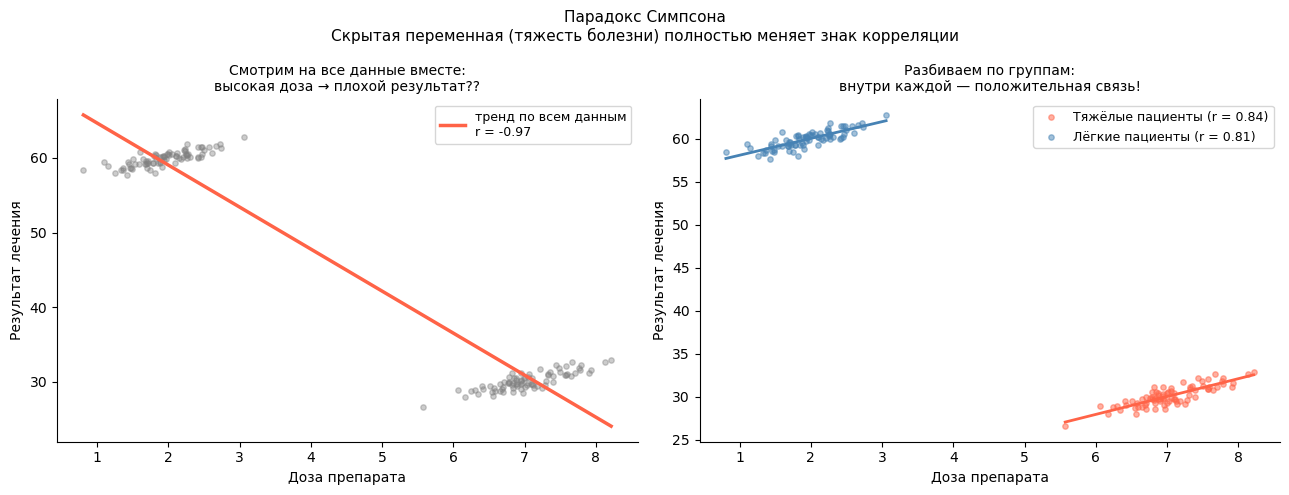

Корреляция на всех данных:            r = -0.97  ← ОТРИЦАТЕЛЬНАЯ!
Корреляция внутри группы A (тяжёлые): r = 0.84  ← положительная
Корреляция внутри группы B (лёгкие):  r = 0.81  ← положительная

Вывод: анализировать корреляцию без учёта групповой структуры данных — опасно.


In [ ]:
# Парадокс Симпсона — наглядная демонстрация
#
# Сценарий: «Доза препарата → Результат лечения»
#
# Группа A (тяжёлые пациенты): получают ВЫСОКИЕ дозы (x ~ 7), исходы ПЛОХИЕ (y ~ 30)
# Группа B (лёгкие пациенты):  получают НИЗКИЕ дозы  (x ~ 2), исходы ХОРОШИЕ (y ~ 60)
#
# Внутри каждой группы: больше доза → лучше результат (+)
# На объединённых данных: высокие дозы → плохой результат (−) ← ложный вывод!
# Причина: скрытая переменная — тяжесть заболевания

np.random.seed(5)
n = 80

xA = np.random.randn(n)*0.5 + 7           # тяжёлые: высокая доза
yA = 2.0*(xA - 7) + np.random.randn(n)*0.6 + 30   # плохой исход, внутри +

xB = np.random.randn(n)*0.5 + 2           # лёгкие: низкая доза
yB = 2.0*(xB - 2) + np.random.randn(n)*0.6 + 60   # хороший исход, внутри +

x_all = np.concatenate([xA, xB])
y_all = np.concatenate([yA, yB])

r_all, _ = stats.pearsonr(x_all, y_all)
r_A, _   = stats.pearsonr(xA, yA)
r_B, _   = stats.pearsonr(xB, yB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(x_all, y_all, alpha=0.4, s=15, color='gray')
m, b = np.polyfit(x_all, y_all, 1)
xx = np.linspace(x_all.min(), x_all.max(), 200)
ax.plot(xx, m*xx+b, color='tomato', linewidth=2.5,
        label=f'тренд по всем данным\nr = {r_all:.2f}')
ax.set_xlabel('Доза препарата'); ax.set_ylabel('Результат лечения')
ax.set_title('Смотрим на все данные вместе:\nвысокая доза → плохой результат??', fontsize=10)
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(xA, yA, alpha=0.5, s=15, color='tomato',
           label=f'Тяжёлые пациенты (r = {r_A:.2f})')
ax.scatter(xB, yB, alpha=0.5, s=15, color='steelblue',
           label=f'Лёгкие пациенты (r = {r_B:.2f})')
for xx_, yy_, col in [(xA, yA, 'tomato'), (xB, yB, 'steelblue')]:
    m_, b_ = np.polyfit(xx_, yy_, 1)
    t = np.linspace(xx_.min(), xx_.max(), 100)
    ax.plot(t, m_*t+b_, color=col, linewidth=2)
ax.set_xlabel('Доза препарата'); ax.set_ylabel('Результат лечения')
ax.set_title('Разбиваем по группам:\nвнутри каждой — положительная связь!', fontsize=10)
ax.legend(fontsize=9)

plt.suptitle(
    'Парадокс Симпсона\n'
    'Скрытая переменная (тяжесть болезни) полностью меняет знак корреляции',
    fontsize=11
)
plt.tight_layout()
plt.show()

print(f"Корреляция на всех данных:            r = {r_all:.2f}  ← ОТРИЦАТЕЛЬНАЯ!")
print(f"Корреляция внутри группы A (тяжёлые): r = {r_A:.2f}  ← положительная")
print(f"Корреляция внутри группы B (лёгкие):  r = {r_B:.2f}  ← положительная")
print()
print("Вывод: анализировать корреляцию без учёта групповой структуры данных — опасно.")

**Как бороться с парадоксом Симпсона:**

1. **Стратификация** — разбейте данные на однородные группы по скрытой переменной и анализируйте корреляцию внутри каждой группы отдельно.
2. **Добавьте скрытую переменную в модель** — в регрессии включите «тяжесть болезни» как признак. Тогда коэффициент при «дозе» будет оценён корректно, с учётом этого фактора.
3. **Разведочный анализ** — всегда смотрите на данные в разрезе возможных группирующих переменных (пол, возраст, группа лечения и т.д.) перед тем как делать выводы об агрегированной корреляции.

> Парадокс Симпсона — главная причина, почему наблюдательные данные сами по себе не доказывают причинно-следственную связь. Для этого нужны рандомизированные эксперименты или методы причинного вывода (causal inference).

---
# Часть IV. Линейная регрессия

## 1. Что такое регрессия и зачем она нужна

Корреляция отвечает на вопрос «есть ли связь?». Регрессия идёт дальше: она строит **модель** этой связи, которую можно использовать для предсказания.

**Задача регрессии:** предсказать числовой таргет $y$ на основе признаков $x_1, x_2, \ldots, x_k$.

Примеры:
- Предсказать цену квартиры по площади, этажу, районе
- Оценить зарплату по годам опыта, образованию, специальности
- Спрогнозировать продажи по расходам на рекламу и сезонности

**В нашем датасете:**
- **Таргет** $y$ = `MedHouseVal` — медианная стоимость дома
- **Признаки** $x_1, \ldots, x_8$ = `MedInc`, `HouseAge`, `AveRooms` и остальные (см. таблицу в начале)

Мы хотим построить модель, которая по характеристикам района предсказывает, сколько стоят дома в нём.

**Почему линейная?** Линейная регрессия предполагает, что таргет — это линейная комбинация признаков. Это сильное допущение, но оно даёт нам прозрачность: каждый коэффициент имеет конкретную интерпретацию.

## 2. Простая линейная регрессия

### Связь с корреляцией

Наклон β₁ в простой регрессии и коэффициент корреляции Пирсона связаны формулой:

$$\beta_1 = r \cdot \frac{s_Y}{s_X}$$

где $s_X$ и $s_Y$ — стандартные отклонения X и Y. Корреляция — это «стандартизованный» наклон: она показывает ту же зависимость, но в безразмерных единицах. Именно поэтому, когда мы стандартизируем признаки (Z-score), стандартизованные коэффициенты регрессии совпадают с корреляцией Пирсона.

**Один предиктор:**
$$\hat{y} = \beta_0 + \beta_1 x$$

- $\beta_0$ — **свободный член (intercept)**: значение $\hat{y}$ при $x = 0$ (часто не имеет физического смысла, но математически необходим)
- $\beta_1$ — **наклон (slope)**: на сколько изменится $\hat{y}$, если $x$ увеличится на 1 единицу

### Метод наименьших квадратов (МНК)

Коэффициенты подбираются так, чтобы минимизировать **RSS (Residual Sum of Squares) — сумму квадратов остатков**:

$$\text{RSS} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2 \to \min$$

Здесь $(y_i - \hat{y}_i)$ — **остаток**: разница между реальным значением и предсказанием модели для $i$-го наблюдения. RSS суммирует квадраты всех этих ошибок — чем меньше RSS, тем точнее прямая описывает данные.

**Почему квадраты, а не модули?** Квадратичная функция дифференцируема везде — это позволяет найти аналитическое решение, приравняв производную к нулю.

**Аналитическое решение МНК:**
$$\beta_1 = \frac{\text{cov}(X, Y)}{s_X^2} = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i-\bar{x})^2}, \qquad \beta_0 = \bar{y} - \beta_1\bar{x}$$

> **Геометрический смысл:** прямая МНК — единственная прямая, для которой сумма квадратов вертикальных отклонений точек от неё минимальна. Она всегда проходит через точку $(\bar{x}, \bar{y})$.

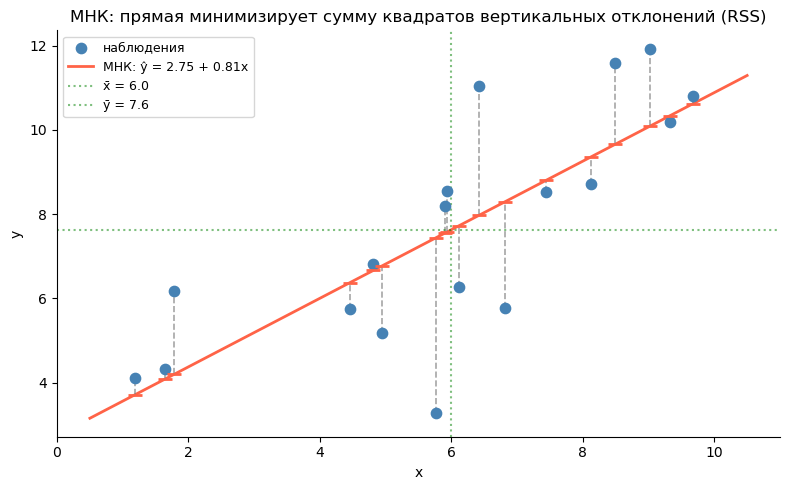

Найденные коэффициенты:  β₀ = 2.7473,  β₁ = 0.8138


In [ ]:
# Геометрия МНК: прямая и вертикальные остатки
np.random.seed(0)
n = 18
x = np.sort(np.random.uniform(1, 10, n))
y = 2.5 + 0.8*x + np.random.randn(n)*1.5

# Аналитический МНК: формулы из теории выше
b1 = np.cov(x, y, ddof=1)[0,1] / np.var(x, ddof=1)
b0 = y.mean() - b1 * x.mean()
y_hat = b0 + b1*x  # предсказания модели

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x, y, zorder=5, s=55, color='steelblue', label='наблюдения')
xx_line = np.linspace(0.5, 10.5, 100)
ax.plot(xx_line, b0 + b1*xx_line, 'tomato', linewidth=2,
        label=f'МНК: ŷ = {b0:.2f} + {b1:.2f}x')

# Вертикальные остатки — серые штрихи от точки до прямой
for xi, yi, yhi in zip(x, y, y_hat):
    ax.vlines(xi, min(yi, yhi), max(yi, yhi),
              color='gray', linewidth=1.2, linestyle='--', alpha=0.7)

# Проекции точек на прямую
ax.scatter(x, y_hat, marker='_', s=100, color='tomato', zorder=6, linewidth=2)

# Точка пересечения средних — через неё всегда проходит МНК-прямая
ax.axvline(x.mean(), color='green', linestyle=':', alpha=0.5, label=f'x̄ = {x.mean():.1f}')
ax.axhline(y.mean(), color='green', linestyle=':', alpha=0.5, label=f'ȳ = {y.mean():.1f}')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('МНК: прямая минимизирует сумму квадратов вертикальных отклонений (RSS)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"Найденные коэффициенты:  β₀ = {b0:.4f},  β₁ = {b1:.4f}")

**Что видно:**
- Серые штриховые линии — остатки $e_i = y_i - \hat{y}_i$: расстояние от реальной точки до предсказания на прямой. МНК минимизирует сумму квадратов этих отрезков.
- Красные тире на прямой — предсказанные значения $\hat{y}_i$.
- Зелёные пунктирные линии — среднее $\bar{x}$ и $\bar{y}$. МНК-прямая всегда проходит через их пересечение.

## 3. Метрики качества регрессионной модели

После обучения нужно оценить, насколько хорошо модель предсказывает. Для этого существует несколько метрик.

### MSE, RMSE, MAE

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2 \qquad \text{RMSE} = \sqrt{\text{MSE}} \qquad \text{MAE} = \frac{1}{n}\sum_{i=1}^n|y_i - \hat{y}_i|$$

| Метрика | Единицы | Чувствительность к выбросам | Когда использовать |
|---|---|---|---|
| MSE | таргет² | высокая (квадрат штрафует сильно) | когда крупные ошибки критичны |
| RMSE | таргет | высокая | удобна для интерпретации (в тех же единицах) |
| MAE | таргет | низкая | когда данные с выбросами, штраф равномерный |

### Коэффициент детерминации R²

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- **TSS** (Total Sum of Squares) — полная дисперсия таргета: насколько наблюдения разбросаны вокруг среднего
- **RSS** — необъяснённая часть: что модель не смогла предсказать
- **R²** — доля дисперсии таргета, объяснённая моделью

**Интуиция R²:** если R² = 0.75, модель «объяснила» 75% разброса таргета. Оставшиеся 25% — неучтённые факторы или шум.


### Adjusted R² (скорректированный коэффициент детерминации)

$$\bar{R}^2 = 1 - \frac{(1 - R^2)(n-1)}{n - k - 1}$$

где $k$ — число признаков в модели. Adjusted R² **штрафует** за добавление лишних признаков: если новый признак не улучшает предсказание, $\bar{R}^2$ снизится или останется прежним.

Правило: при сравнении моделей с разным числом признаков смотрите на Adjusted R², а не на обычный R² — иначе будет казаться, что «чем больше признаков, тем лучше».

| Adjusted R² | Интерпретация |
|---|---|
| ≈ R² | признаков мало относительно размера выборки |
| Adjusted R² ≪ R² | модель «перегружена» признаками, часть из них лишние |
| Adjusted R² < 0 | модель хуже наивного предсказания средним |

**Обычный R² — для понимания качества одной модели:**

| R² | Интерпретация |
|---|---|
| > 0.9 | очень сильная модель (проверьте на переобучение!) |
| 0.7–0.9 | хорошая модель |
| 0.4–0.7 | умеренная |
| < 0.4 | слабая |
| < 0 | модель хуже наивного предсказания средним |

> **Важно:** R² всегда считайте на **тестовой** (отложенной) выборке. На обучающей он искусственно завышен.

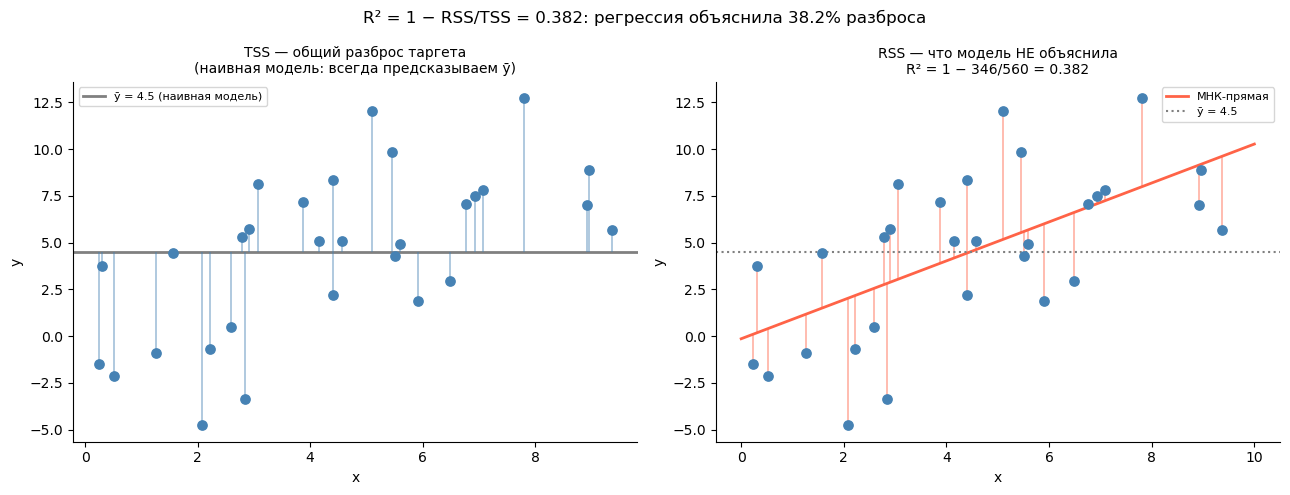

In [ ]:
# Геометрический смысл R²: TSS vs RSS
from sklearn.linear_model import LinearRegression
np.random.seed(3)
n = 30
x = np.random.uniform(0, 10, n)
y = 1.2*x + np.random.randn(n)*3

model_demo = LinearRegression().fit(x.reshape(-1,1), y)
y_hat_demo = model_demo.predict(x.reshape(-1,1))
y_bar = y.mean()

tss = np.sum((y - y_bar)**2)
rss = np.sum((y - y_hat_demo)**2)
r2  = 1 - rss/tss

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, show_model in zip(axes, [False, True]):
    ax.scatter(x, y, s=45, color='steelblue', zorder=5)
    if show_model:
        xx_ = np.linspace(0, 10, 100)
        ax.plot(xx_, model_demo.predict(xx_.reshape(-1,1)),
                'tomato', linewidth=2, label='МНК-прямая')
        for xi, yi, yhi in zip(x, y, y_hat_demo):
            ax.vlines(xi, min(yi,yhi), max(yi,yhi),
                      color='tomato', linewidth=1.2, alpha=0.5)
        ax.axhline(y_bar, color='gray', linestyle=':', linewidth=1.5,
                   label=f'ȳ = {y_bar:.1f}')
        ax.set_title(f'RSS — что модель НЕ объяснила\nR² = 1 − {rss:.0f}/{tss:.0f} = {r2:.3f}',
                     fontsize=10)
        ax.legend(fontsize=8)
    else:
        ax.axhline(y_bar, color='gray', linestyle='-', linewidth=2,
                   label=f'ȳ = {y_bar:.1f} (наивная модель)')
        for xi, yi in zip(x, y):
            ax.vlines(xi, min(yi, y_bar), max(yi, y_bar),
                      color='steelblue', linewidth=1.2, alpha=0.5)
        ax.set_title(f'TSS — общий разброс таргета\n(наивная модель: всегда предсказываем ȳ)',
                     fontsize=10)
        ax.legend(fontsize=8)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'R² = 1 − RSS/TSS = {r2:.3f}: регрессия объяснила {r2*100:.1f}% разброса',
             fontsize=12)
plt.tight_layout()
plt.show()

---
# Часть V. Множественная линейная регрессия

## 1. От одного признака к нескольким

Реальные явления редко определяются одной переменной. Цена квартиры зависит от площади, **и** от этажа, **и** от района. Множественная регрессия учитывает всё это одновременно.

**В нашем случае** таргет `MedHouseVal` зависит сразу от всех 8 признаков датасета — доходов, возраста домов, географии и т.д.

**Модель с k предикторами:**
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_k x_k$$

### Интерпретация коэффициентов

**Intercept β₀** в множественной регрессии — значение таргета, когда **все** признаки одновременно равны нулю. На практике это почти никогда не имеет содержательного смысла (нет дома с нулевым доходом, нулевым числом комнат и нулевыми координатами). Intercept нужен модели для математической корректности — он смещает прямую так, чтобы она проходила через центр данных. **Не интерпретируйте β₀ содержательно, если ноль не входит в реальный диапазон признаков.**

$\beta_j$ — **частный эффект**: изменение $\hat{y}$ при увеличении $x_j$ на 1 единицу **при фиксированных остальных признаках**.

Например, $\beta_{\text{MedInc}}$ показывает, на сколько изменится предсказанная цена дома при росте медианного дохода на единицу — при условии, что возраст домов, число комнат и остальные признаки остаются неизменными.

---

## 2. Разбиение на обучающую и тестовую выборки

Прежде чем обучать модель, нужно зарезервировать часть данных для проверки её качества.

**Зачем это нужно?** Если оценивать модель на тех же данных, на которых она обучалась, результат будет оптимистично завышен: модель могла просто «запомнить» обучающие примеры. Честная оценка — только на данных, которые модель не видела.

**Стандартная практика:**
- **Обучающая выборка (train)** — 80% данных. На ней модель подбирает коэффициенты.
- **Тестовая выборка (test)** — 20% данных. На ней мы оцениваем, насколько хорошо модель обобщается на новые данные.

```
Все данные (20 640 строк)
├── Train: 16 512 строк  →  модель учится
└── Test:   4 128 строк  →  мы проверяем
```

`random_state=42` фиксирует случайное разбиение — чтобы результаты воспроизводились при повторном запуске.

### Импорты: машинное обучение (sklearn)

`train_test_split` — разбить данные на обучение и тест. `LinearRegression` — модель линейной регрессии. `r2_score`, `mean_squared_error` — метрики качества.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

best_feat = df[feature_cols].corrwith(y).abs().idxmax()

# Простая
lr_simple = LinearRegression().fit(X_train[[best_feat]], y_train)
yp_simple = lr_simple.predict(X_test[[best_feat]])

# Множественная
lr_multi = LinearRegression().fit(X_train, y_train)
yp_multi = lr_multi.predict(X_test)

print(f"{'Модель':<32} {'R² test':>8} {'RMSE test':>10} {'Признаков':>10}")
print("─" * 65)
for name, yp, nf in [
    ("Простая (1 признак)", yp_simple, 1),
    ("Множественная (все)", yp_multi, len(feature_cols))
]:
    print(f"{name:<32} {r2_score(y_test,yp):>8.4f}"
          f" {mean_squared_error(y_test,yp)**0.5:>10.4f} {nf:>10}")

print()
print("Коэффициенты множественной модели (нестандартизованные):")
coef_raw = pd.DataFrame({'признак': feature_cols,
                          'β': lr_multi.coef_})                 .sort_values('β', key=abs, ascending=False)
print(coef_raw.to_string(index=False))

Модель                            R² test  RMSE test  Признаков
─────────────────────────────────────────────────────────────────
Простая (1 признак)                0.4589     0.8421          1
Множественная (все)                0.5758     0.7456          8

Коэффициенты множественной модели (нестандартизованные):
   признак         β
 AveBedrms  0.783145
    MedInc  0.448675
 Longitude -0.433708
  Latitude -0.419792
  AveRooms -0.123323
  HouseAge  0.009724
  AveOccup -0.003526
Population -0.000002


## 3. Масштабирование признаков

Сравнивать коэффициенты напрямую в несравнимых единицах **нельзя**. Если один признак измеряется в тысячах долларов, а другой — в комнатах от 1 до 10, то коэффициент при первом будет в тысячи раз меньше — не потому что признак менее важен, а просто из-за разных единиц.

**Решение: стандартизация (Z-score)**
$$x_j^* = \frac{x_j - \mu_j}{\sigma_j}$$

После стандартизации каждый признак имеет среднее 0 и стандартное отклонение 1. Тогда $\beta_j$ показывает изменение таргета в ответ на изменение признака на **одно стандартное отклонение**.

> ⚠️ **Важно:** `StandardScaler` нужно обучать (`fit`) **только на тренировочных данных**. Применять (`transform`) — и к тренировочным, и к тестовым. Если обучить scaler на всей выборке, тестовые данные «утекут» в обучение — это называется **data leakage**.

### Импорты: масштабирование признаков

`StandardScaler` приводит каждый признак к среднему 0 и стандартному отклонению 1. Это необходимо для корректного сравнения коэффициентов регрессии.

In [ ]:
from sklearn.preprocessing import StandardScaler

Сравнение коэффициентов до и после стандартизации:
   признак  β (сырой)  β (стандартиз.)
  Latitude    -0.4198          -0.8969
 Longitude    -0.4337          -0.8698
    MedInc     0.4487           0.8544
 AveBedrms     0.7831           0.3393
  AveRooms    -0.1233          -0.2944
  HouseAge     0.0097           0.1225
  AveOccup    -0.0035          -0.0408
Population    -0.0000          -0.0023

R² (стандартиз.) = 0.5758  ← метрика не меняется, только интерпретация коэффициентов


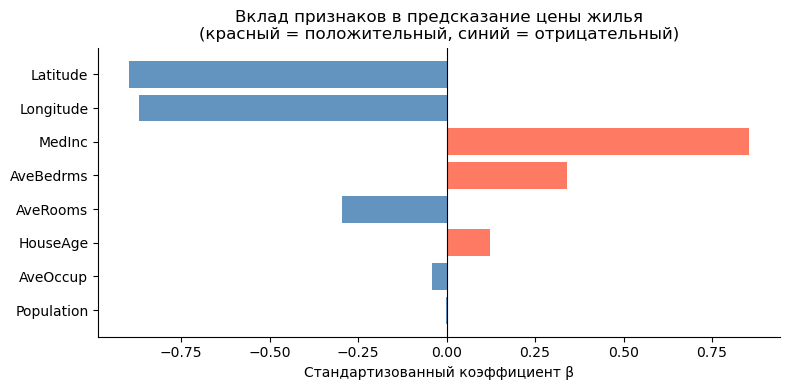

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform на train
X_test_sc  = scaler.transform(X_test)         # только transform на test

lr_scaled = LinearRegression().fit(X_train_sc, y_train)
yp_scaled = lr_scaled.predict(X_test_sc)

coef_compare = pd.DataFrame({
    'признак':          feature_cols,
    'β (сырой)':        lr_multi.coef_.round(4),
    'β (стандартиз.)':  lr_scaled.coef_.round(4),
}).sort_values('β (стандартиз.)', key=abs, ascending=False)

print("Сравнение коэффициентов до и после стандартизации:")
print(coef_compare.to_string(index=False))
print(f"\nR² (стандартиз.) = {r2_score(y_test, yp_scaled):.4f}  "
      f"← метрика не меняется, только интерпретация коэффициентов")

# Визуализация стандартизованных коэффициентов
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if v > 0 else 'steelblue' for v in lr_scaled.coef_]
order = np.argsort(np.abs(lr_scaled.coef_))
ax.barh([feature_cols[i] for i in order],
        [lr_scaled.coef_[i] for i in order],
        color=[colors[i] for i in order], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Стандартизованный коэффициент β')
ax.set_title('Вклад признаков в предсказание цены жилья\n'
             '(красный = положительный, синий = отрицательный)')
plt.tight_layout()
plt.show()

Теперь мы можем сравнивать: `MedInc` — самый важный предиктор, его $\beta$ больше по модулю, чем у всех остальных. `AveOccup` (среднее число жильцов) отрицателен: чем больше жильцов на дом, тем ниже цена.

---
# Часть VI. Мультиколлинеарность

## 1. Что такое мультиколлинеарность и почему она проблема

**Мультиколлинеарность** — когда два или более предикторов сильно коррелируют друг с другом.

**Пример:** в данных о квартирах «площадь кухни» и «общая площадь» почти всегда растут вместе. Если включить оба признака в регрессию, модель не сможет понять, кто из них «виноват» в росте цены — и даст неустойчивые, случайные коэффициенты.

**Почему это проблема:**
- Матрица $\mathbf{X}^\top\mathbf{X}$ становится плохо обусловленной (близка к вырожденной)
- Стандартные ошибки коэффициентов раздуваются — p-value ненадёжны
- Значимый признак может выглядеть незначимым, и наоборот
- Коэффициенты нестабильны: маленькое изменение данных → большое изменение $\beta$

**Как обнаружить:**
1. Смотреть на корреляционную матрицу предикторов (|r| > 0.8 — тревожный сигнал)
2. Вычислить **VIF**

## 2. VIF — Variance Inflation Factor

VIF количественно измеряет мультиколлинеарность для каждого признака отдельно.

**Идея:** для признака $x_j$ строим вспомогательную регрессию — предсказываем $x_j$ по всем остальным признакам. Если $R^2_j$ этой регрессии высок, значит $x_j$ хорошо объясняется другими признаками — он «лишний» или почти лишний.

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

| VIF | Интерпретация |
|---|---|
| = 1 | нет мультиколлинеарности |
| 1–5 | умеренная, как правило допустима |
| 5–10 | высокая, требует внимания |
| > 10 | критическая, рекомендуется удалить или объединить признаки |

**Что делать при высоком VIF:**
1. Удалить один из коллинеарных признаков (итеративно: удалить с наибольшим VIF, пересчитать)
2. Объединить признаки в один (например, среднее или PCA)
3. Применить регуляризацию (Ridge — особенно хорошо справляется с мультиколлинеарностью)

### Импорты: диагностика мультиколлинеарности

`variance_inflation_factor` из `statsmodels` вычисляет VIF для каждого признака.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF для California Housing:
   признак        VIF
 Longitude 633.711654
  Latitude 559.874071
  AveRooms  45.993601
 AveBedrms  43.590314
    MedInc  11.511140
  HouseAge   7.195917
Population   2.935745
  AveOccup   1.095243


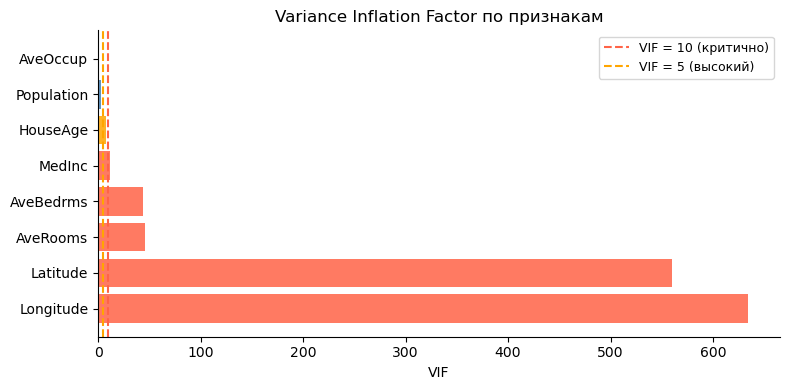

In [ ]:
X_vif = df[feature_cols].copy()
vif_df = pd.DataFrame({
    'признак': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print("VIF для California Housing:")
print(vif_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
          for v in vif_df['VIF']]
ax.barh(vif_df['признак'], vif_df['VIF'], color=colors, alpha=0.85)
ax.axvline(10, color='tomato', linestyle='--', linewidth=1.5, label='VIF = 10 (критично)')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (высокий)')
ax.set_xlabel('VIF'); ax.set_title('Variance Inflation Factor по признакам')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
# Часть VII. Статистический вывод: statsmodels

## 1. Зачем нужен statsmodels, если есть sklearn

`sklearn` — инструмент для **предсказания**: он обучает модель и оценивает её качество на тестовой выборке. Он не отвечает на вопрос «какие именно признаки важны и насколько мы в этом уверены».

`statsmodels` — инструмент для **статистического вывода**: он отвечает на вопросы:
- Значим ли этот коэффициент статистически, или он мог возникнуть случайно?
- Каков доверительный интервал для коэффициента?
- Значима ли модель в целом?

| | sklearn | statsmodels |
|---|---|---|
| Предсказание (R², MSE) | ✓ | ✓ |
| Коэффициенты β | ✓ | ✓ |
| p-value признаков | ✗ | ✓ |
| Доверительные интервалы | ✗ | ✓ |
| F-тест модели в целом | ✗ | ✓ |
| AIC / BIC | ✗ | ✓ |
| Диагностика остатков (тесты) | ✗ | ✓ |

На практике часто используют оба: `sklearn` — для подбора модели и оценки на тестовой выборке, `statsmodels` — для интерпретации значимости признаков.

> **Важно:** `statsmodels` не добавляет константу автоматически. Нужно явно вызвать `sm.add_constant(X)`.

### Импорты: статистический вывод

`statsmodels.api` (обычно импортируется как `sm`) предоставляет полноценный статистический вывод: p-value коэффициентов, доверительные интервалы, F-тест, AIC/BIC.

In [ ]:
import statsmodels.api as sm

In [ ]:
# Обучаем OLS через statsmodels
# Сразу используем признаки без сильной мультиколлинеарности
high_vif = vif_df[vif_df['VIF'] > 10]['признак'].tolist()
final_features = [f for f in feature_cols if f not in high_vif]
print(f"Исключены (VIF > 10): {high_vif}")
print(f"Оставлено признаков:  {final_features}")

X_sm_train = sm.add_constant(X_train[final_features])
model_ols  = sm.OLS(y_train, X_sm_train).fit()
print(model_ols.summary())

Исключены (VIF > 10): ['Longitude', 'Latitude', 'AveRooms', 'AveBedrms', 'MedInc']
Оставлено признаков:  ['HouseAge', 'Population', 'AveOccup']
                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     63.22
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.23e-40
Time:                        00:25:05   Log-Likelihood:                -25732.
No. Observations:               16512   AIC:                         5.147e+04
Df Residuals:                   16508   BIC:                         5.150e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025

## 2. Как читать `.summary()`

### Верхний блок — общие характеристики модели

| Поле | Значение |
|---|---|
| `R-squared` | доля объяснённой дисперсии **на обучении** |
| `Adj. R-squared` | с поправкой на число признаков — штрафует за добавление лишних переменных |
| `F-statistic` | тест H₀: все коэффициенты кроме константы равны нулю |
| `Prob (F-statistic)` | p-value F-теста; если < 0.05 — модель значима в целом |
| `AIC / BIC` | критерии для **сравнения** моделей между собой (меньше = лучше) |

### Средний блок — коэффициенты

| Поле | Значение |
|---|---|
| `coef` | значение коэффициента $\hat{\beta}_j$ |
| `std err` | стандартная ошибка: насколько точно оценён $\beta_j$ |
| `t` | t-статистика = coef / std err |
| `P>\|t\|` | p-value: H₀ — данный $\beta_j = 0$; если < 0.05, признак значим |
| `[0.025  0.975]` | 95% доверительный интервал для $\beta_j$ |

**Интерпретация p-value признака:** если p > 0.05, нет оснований утверждать, что этот признак влияет на таргет (при фиксированных остальных). Признак — кандидат на исключение.

### Нижний блок — диагностика остатков

| Поле | Значение |
|---|---|
| `Omnibus` / `Jarque-Bera` | тесты на нормальность остатков (H₀: нормальны) |
| `Durbin-Watson` | тест на автокорреляцию остатков (норма ≈ 2; < 1 или > 3 — проблема) |
| `Cond. No.` | число обусловленности матрицы X (> 1000 — сигнал мультиколлинеарности) |

---
# Шпаргалка по инструментам

```python
# ── Корреляция ────────────────────────────────────────────────────────────
r, p   = stats.pearsonr(x, y)         # Пирсон: линейная связь
rho, p = stats.spearmanr(x, y)        # Спирмен: монотонная связь
df.corr(method='pearson')             # корреляционная матрица
sns.heatmap(matrix, cmap='coolwarm')  # тепловая карта
sns.pairplot(df, diag_kind='kde')     # scatter matrix

# ── Регрессия (sklearn) ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit только на train!
X_test_sc  = scaler.transform(X_test)

model = LinearRegression().fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
r2_score(y_test, y_pred)
mean_squared_error(y_test, y_pred) ** 0.5   # RMSE

# ── Мультиколлинеарность ──────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = variance_inflation_factor(X.values, j)  # VIF для j-го признака

# ── Статистический вывод (statsmodels) ───────────────────────────────────
import statsmodels.api as sm
X_with_const = sm.add_constant(X_train)
model_ols = sm.OLS(y_train, X_with_const).fit()
model_ols.summary()      # полная сводка: p-value, CI, F-тест, AIC
model_ols.pvalues        # p-value для каждого признака
model_ols.conf_int()     # 95%% доверительные интервалы
```